In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')


import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1

,300,301,302,303,304,305,306,307,308,309,...,RDkit_fr_sulfide,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_term_acetylene,RDkit_fr_tetrazole,RDkit_fr_thiazole,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_fr_urea,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_0000,-0.451604,0.508020,-0.215841,0.279434,-0.177561,-0.714216,0.962861,0.353974,0.372018,0.283712,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.442464
A2ARDataset_0001,-0.580816,0.661863,-0.196615,0.414776,-0.178242,-0.572745,0.862649,0.331915,0.451654,0.373833,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.442464
A2ARDataset_0002,-0.149355,0.020688,-0.017025,0.351651,-0.464647,-0.758257,0.899988,0.121955,0.597253,0.313429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.335977
A2ARDataset_0003,-0.221894,0.101965,0.058321,0.376781,-0.432157,-0.659786,0.939272,0.103234,0.660293,0.480575,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.374079
A2ARDataset_0004,-0.497377,0.512645,0.018194,0.279497,-0.382501,-0.760101,0.666209,0.327176,0.513706,0.454725,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.371188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_7851,-0.662869,0.594725,0.420540,0.181816,0.006698,-0.819028,0.484375,0.166745,0.425275,0.149207,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.384736
A2ARDataset_7852,0.208791,0.713855,0.259613,0.296591,-0.001371,-0.784151,0.559925,0.239590,0.084138,0.329249,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.450544
A2ARDataset_7853,-0.144258,0.504814,0.374749,0.618364,-0.061048,-0.881780,0.464672,0.045130,0.103850,0.169520,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.477657


In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [7]:
n_components

1854

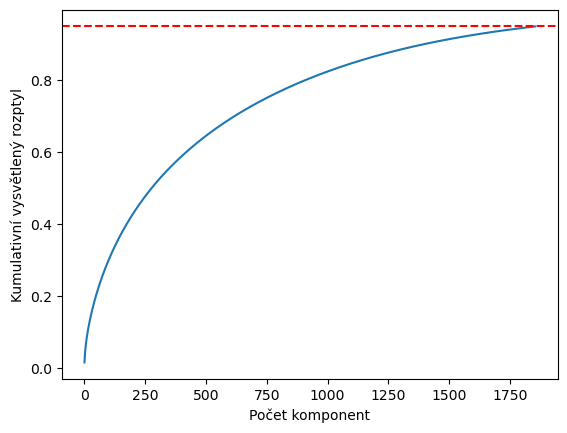

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [9]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/Applications/DataSpell.app/Contents/plugins/python-ce/helpers-pro/jupyter_debug', '/Applications/DataSpell.app/Contents/plugins/python-ce/helpers/pydev', '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [10]:
import optuna
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    # Návrh hyperparametrů pro dopřednou neuronovou síť
    params = {
        'dropout_frac': trial.suggest_float("dropout_frac", 0, 0.9),
        'patience': trial.suggest_int("patience", 10, 200),
        'tol': trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True),
        'n_epochs': trial.suggest_int("n_epochs", 200, 2000),
        'batch_size': trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024]),
        'optimizer': trial.suggest_categorical("optimizer", ["AdamW", "RMSprop"]),
        'lr': trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]),
        'neuron_layers': trial.suggest_categorical("neuron_layers_size", ["[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[4096, 1024, 256, 64, 8]", "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]", "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]", "[200]", "[2000]", "[2000, 1000]", "[2000, 1000, 500]", "[1000, 50]", "[4000, 2000]", "[4000, 2000, 1000, 500]", "[4000, 2000, 2000, 500]"])
    }

    neuron_layers_dict = {
        "[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 1024, 256, 64, 8]": [4096, 1024, 256, 64, 8],
        "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]": [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]": [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
        "[200]": [200],
        "[2000]": [2000],
        "[2000, 1000]": [2000, 1000],
        "[2000, 1000, 500]": [2000, 1000, 500],
        "[1000, 50]": [1000, 50],
        "[4000, 2000]": [4000, 2000],
        "[4000, 2000, 1000, 500]": [4000, 2000, 1000, 500],
        "[4000, 2000, 2000, 500]": [4000, 2000, 2000, 500]
    }
    params['neuron_layers'] = neuron_layers_dict[params['neuron_layers']]
    opt_func = optim.AdamW if params['optimizer'] == "AdamW" else optim.RMSprop

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        device=device,
        act_fun=F.selu,
        dropout_frac=params['dropout_frac'],
        patience=params['patience'],
        tol=params['tol'],  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=params['weight_decay'],
        n_epochs=params['n_epochs'],
        neuron_layers=params['neuron_layers'],  # Použití neuron_layers_size
        batch_size=params['batch_size'],
        optimizer=opt_func,
        lr=params['lr'],
    )
    # Trénink a predikce
    model.fit(X_train, y_train, X_val, y_val)
    preds = model.predict(X_val)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_val, preds_bin)
    acc = accuracy_score(y_val, preds_bin)
    mcc = matthews_corrcoef(y_val, preds_bin)

    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_val, preds_bin))
    return mcc  # maximalizujeme MCC


In [ ]:
study = optuna.create_study(
    study_name="hERG_nn_without_smote",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-05-20 19:24:50,540] A new study created in RDB with name: hERG_nn_without_smote


42


array([[   0, 1297],
       [   0, 1836]])

[I 2025-05-20 19:28:25,362] Trial 0 finished with value: 0.0 and parameters: {'dropout_frac': 0.4869575584917002, 'patience': 190, 'tol': 1.675624004858589e-05, 'weight_decay': 0.013505452722690364, 'n_epochs': 1649, 'batch_size': 512, 'optimizer': 'RMSprop', 'lr': 0.001, 'neuron_layers_size': '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 0 with value: 0.0.


42


...

[I 2025-05-20 22:46:00,610] Trial 90 finished with value: 0.38785157559368044 and parameters: {'dropout_frac': 0.15682220677969477, 'patience': 187, 'tol': 0.0005162760999792217, 'weight_decay': 0.0003110316564091188, 'n_epochs': 1325, 'batch_size': 256, 'optimizer': 'AdamW', 'lr': 0.1, 'neuron_layers_size': '[4000, 2000, 2000, 500]'}. Best is trial 14 with value: 0.42186053409977586.


42


array([[ 332,  965],
       [ 242, 1594]])

[I 2025-05-20 22:47:18,395] Trial 91 finished with value: 0.1580962600499099 and parameters: {'dropout_frac': 0.6564287228466715, 'patience': 139, 'tol': 0.0005196072321705048, 'weight_decay': 6.888974590849733e-06, 'n_epochs': 313, 'batch_size': 1024, 'optimizer': 'AdamW', 'lr': 0.01, 'neuron_layers_size': '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 14 with value: 0.42186053409977586.


42


In [ ]:

model = STFullyConnected(
        n_dim=X1.shape[1],
        n_class=1,
        device="cuda",
        act_fun=F.selu,
        dropout_frac=0.7587301567075606,
        patience=0.00010905325401069917,
        tol=0,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=0.024542235145206714,
        n_epochs=403,
        neuron_layers= [200],  # Použití neuron_layers_size
        batch_size=128,
        optimizer=optim.AdamW,
        lr=1e-06,
    print_outputs= 2
    )
model.fit(X1,y1,X2,y2) #0.6084853456048988

In [ ]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

In [ ]:
preds = model.predict(X3)
preds_bin = preds > 0.5

    # Metiky
f1 = f1_score(y3, preds_bin)
acc = accuracy_score(y3, preds_bin)
mcc = matthews_corrcoef(y3, preds_bin)

In [ ]:
display(mcc) # 0.17324800323685596

In [ ]:
study_4.best_params